# **Compulsory Assignment 2**
## *Machine Learning and Deep Learning (CDSCO2041C)*
*Group: MLS26_CA02*

*Student IDs: 185912, 161989, 160714 & 160363*

*Dataset: _eth_dkk.csv & _XCSE_NOVO-1.csv*

---

# Investment Choice between Ethereum and Novo Nordisk using RoI
## Introduction

In this report, our group investigates how an investor with DKK 250,000 in available cash should allocate capital between a cryptocurrency and an individual equity. Following the assignment setup, we focus on Ethereum as the cryptocurrency candidate, motivated by its lower price level relative to Bitcoin and its perceived growth potential, while Novo Nordisk represents the equity alternative due to the availability of historical market data for one of Denmark’s largest listed companies.


Our analysis is structured around Return on Investment (RoI) as the main performance metric, using the provided datasets for Ethereum priced in DKK and for Novo Nordisk listed on the Copenhagen exchange. We first establish a consistent data foundation by cleaning, aligning, and transforming the two time series into comparable return and RoI measures. Building on this, we evaluate which asset has historically offered the highest risk adjusted returns and whether the observed differences are stable across market conditions.


---

## 1. Asset Selection

Should you invest in cryptocurrency (Ethereum) or in equity (Novo Nordisk stock)?

---

In [1]:
# Imports and reproducibility
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from IPython.display import display

np.random.seed(42)

# Style helpers
def set_clean_theme():
    sns.set_theme(style="white", context="notebook")
    plt.rcParams["figure.facecolor"] = "white"
    plt.rcParams["axes.facecolor"] = "white"
    plt.rcParams["axes.grid"] = False

def clean_ax(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=9)

def caption_title(title):
    if title is None:
        return ""
    t = str(title).strip()
    return t[:-1] if t.endswith(".") else t

FIG_W = 9.5

def fig_ax(height):
    fig, ax = plt.subplots(figsize=(FIG_W, height))
    return fig, ax

table_no = 1
figure_no = 1

def print_table(title):
    global table_no
    print(f"Table {table_no}: {caption_title(title)}")
    table_no += 1

def print_figure(title):
    global figure_no
    print(f"Figure {figure_no}: {caption_title(title)}")
    figure_no += 1

ASSET_LABELS = {"eth": "Ethereum (DKK)", "novo": "Novo Nordisk (XCSE)"}
PAL_10 = sns.color_palette("rocket_r", 10)
ASSET_PALETTE = {
    ASSET_LABELS["eth"]: PAL_10[2],
    ASSET_LABELS["novo"]: PAL_10[6],
}

set_clean_theme()


In [2]:
# Load, clean, sort, and store ETH and NOVO as full dataframes, plus merged on Novo dates
def _find(name):
    for candidate in [name, os.path.join("Data", name), os.path.join("..", name)]:
        if os.path.exists(candidate):
            return candidate
    raise FileNotFoundError(f"Cannot find {name}. Place it next to this notebook or in a Data/ subfolder.")

ETH_Path = _find("_eth_dkk.csv")
NOVO_Path = _find("_XCSE_NOVO-1.csv")

eth_raw = pd.read_csv(ETH_Path, sep=";", engine="python")
novo_raw = pd.read_csv(NOVO_Path, sep=",", engine="python", skipinitialspace=True, quotechar='"')

eth_raw.columns = eth_raw.columns.str.replace('"', "", regex=False).str.strip()
novo_raw.columns = novo_raw.columns.str.replace('"', "", regex=False).str.strip()

eth_raw = eth_raw.rename(columns={
    "Dato": "Date",
    "Åbning": "Open",
    "Høj": "High",
    "Lav": "Low",
    "Luk": "Close",
    "Volumen": "Volume",
    "Markedsværdi": "Market Cap",
    "Ændring, %": "Change, %"
})

eth_raw["Date"] = pd.to_datetime(
    eth_raw["Date"].astype(str).str.replace('"', "", regex=False).str.strip(),
    format="%Y-%m-%d",
    errors="coerce"
)

novo_raw["Date"] = pd.to_datetime(
    novo_raw["Date"].astype(str).str.replace('"', "", regex=False).str.strip(),
    format="%m/%d/%Y",
    errors="coerce"
)

for col in ["Open", "High", "Low", "Close", "Volume"]:
    if col in eth_raw.columns:
        eth_raw[col] = eth_raw[col].astype(str).str.replace('"', "", regex=False).str.strip()
        eth_raw[col] = eth_raw[col].str.replace(",", "", regex=False)
        eth_raw[col] = pd.to_numeric(eth_raw[col], errors="coerce")
    if col in novo_raw.columns:
        novo_raw[col] = novo_raw[col].astype(str).str.replace('"', "", regex=False).str.strip()
        novo_raw[col] = novo_raw[col].str.replace(",", "", regex=False)
        novo_raw[col] = novo_raw[col].str.replace(" ", "", regex=False)
        novo_raw[col] = novo_raw[col].str.replace(r"^\.", "", regex=True)
        novo_raw[col] = pd.to_numeric(novo_raw[col], errors="coerce")

eth_df = eth_raw.dropna(subset=["Date"]).drop_duplicates("Date").sort_values("Date").reset_index(drop=True)
novo_df = novo_raw.dropna(subset=["Date"]).drop_duplicates("Date").sort_values("Date").reset_index(drop=True)

eth_close = eth_df[["Date", "Close"]].dropna().rename(columns={"Date": "date", "Close": "close_eth"})
novo_close = novo_df[["Date", "Close"]].dropna().rename(columns={"Date": "date", "Close": "close_novo"})

merged_df = (
    pd.merge(eth_close, novo_close, on="date", how="inner")
      .sort_values("date")
      .reset_index(drop=True)
)

print("ETH rows (full):", len(eth_df))
print("NOVO rows (full):", len(novo_df))
print("Merged rows (Novo trading days):", len(merged_df))


ETH rows (full): 366
NOVO rows (full): 250
Merged rows (Novo trading days): 248


In [3]:
# Create standalone price series and aligned series on Novo trading days
eth_px = eth_df[["Date", "Close"]].dropna().rename(columns={"Date": "date", "Close": "close_eth"}).copy()
novo_px = novo_df[["Date", "Close"]].dropna().rename(columns={"Date": "date", "Close": "close_novo"}).copy()

eth_px = eth_px.sort_values("date").reset_index(drop=True)
novo_px = novo_px.sort_values("date").reset_index(drop=True)

aligned_px = merged_df.copy()
aligned_px = aligned_px.sort_values("date").reset_index(drop=True)

display(eth_px.head(3))
display(novo_px.head(3))
display(aligned_px.head(3))

,date,close_eth
0,2025-03-01,15935.94
1,2025-03-02,18097.15
2,2025-03-03,15303.53


,date,close_novo
0,2025-02-27,641.8
1,2025-02-28,644.5
2,2025-03-03,639.1


,date,close_eth,close_novo
0,2025-03-03,15303.53,639.1
1,2025-03-04,15280.70,616.2
2,2025-03-05,15494.54,631.5


In [4]:
# Compute log returns, simple returns, and cumulative RoI for each asset on its own calendar
def add_returns_and_roi(df, price_col):
    out = df.copy()
    out["log_price"] = np.log(out[price_col])
    out["log_ret"] = out["log_price"].diff()
    out["ret"] = out[price_col].pct_change()
    out["roi"] = out[price_col] / out[price_col].iloc[0] - 1.0
    return out

eth_ts = add_returns_and_roi(eth_px, "close_eth")
novo_ts = add_returns_and_roi(novo_px, "close_novo")

display(eth_ts.head(5))
display(novo_ts.head(5))

,date,close_eth,log_price,log_ret,ret,roi
0,2025-03-01,15935.94,9.676332,NaN,NaN,0.000000
1,2025-03-02,18097.15,9.803510,0.127178,0.135619,0.135619
2,2025-03-03,15303.53,9.635839,-0.167671,-0.154368,-0.039685
3,2025-03-04,15280.70,9.634346,-0.001493,-0.001492,-0.041117
4,2025-03-05,15494.54,9.648243,0.013897,0.013994,-0.027698


,date,close_novo,log_price,log_ret,ret,roi
0,2025-02-27,641.8,6.464277,NaN,NaN,0.000000
1,2025-02-28,644.5,6.468475,0.004198,0.004207,0.004207
2,2025-03-03,639.1,6.460061,-0.008414,-0.008379,-0.004207
3,2025-03-04,616.2,6.423572,-0.036489,-0.035832,-0.039888
4,2025-03-05,631.5,6.448098,0.024526,0.024830,-0.016049


In [5]:
# Compute returns and RoI on the aligned dataset to support comparisons and portfolio work
aligned_ts = aligned_px.copy()
aligned_ts["log_ret_eth"] = np.log(aligned_ts["close_eth"]).diff()
aligned_ts["log_ret_novo"] = np.log(aligned_ts["close_novo"]).diff()
aligned_ts["ret_eth"] = aligned_ts["close_eth"].pct_change()
aligned_ts["ret_novo"] = aligned_ts["close_novo"].pct_change()
aligned_ts["roi_eth"] = aligned_ts["close_eth"] / aligned_ts["close_eth"].iloc[0] - 1.0
aligned_ts["roi_novo"] = aligned_ts["close_novo"] / aligned_ts["close_novo"].iloc[0] - 1.0

display(aligned_ts.head(3))

,date,close_eth,close_novo,log_ret_eth,log_ret_novo,ret_eth,ret_novo,roi_eth,roi_novo
0,2025-03-03,15303.53,639.1,NaN,NaN,NaN,NaN,0.000000,0.000000
1,2025-03-04,15280.70,616.2,-0.001493,-0.036489,-0.001492,-0.035832,-0.001492,-0.035832
2,2025-03-05,15494.54,631.5,0.013897,0.024526,0.013994,0.024830,0.012481,-0.011892


### 1.1 Risk-Adjusted Return: Sharpe Ratio and Volatility

The Sharpe ratio is the most widely used metric for comparing return per unit of risk across assets. It is defined as the annualised mean return divided by annualised volatility, using a zero risk-free rate as a conservative baseline. This connects directly to RoI: an asset with a higher cumulative RoI is not necessarily preferable if it required the investor to absorb far greater daily swings to get there. The Sharpe ratio normalises for this, allowing a fair comparison between Ethereum, which trades continuously and exhibits high daily volatility, and Novo Nordisk, which trades on exchange hours and has historically lower but recently negative returns. A Sharpe ratio above zero means the asset compensated the investor for its risk over the period; below zero means it did not.


In [6]:
# Summary statistics and Sharpe ratio for the aligned return series
def summary_stats(ret_series, label, ann_factor=252):
    r = ret_series.dropna()
    mu_ann = r.mean() * ann_factor
    vol_ann = r.std() * (ann_factor ** 0.5)
    sharpe = mu_ann / vol_ann if vol_ann > 0 else float('nan')
    skew = sp_stats.skew(r)
    kurt = sp_stats.kurtosis(r)
    return {
        'Asset': label,
        'Ann. Return': f'{mu_ann:.2%}',
        'Ann. Volatility': f'{vol_ann:.2%}',
        'Sharpe Ratio': f'{sharpe:.3f}',
        'Skewness': f'{skew:.3f}',
        'Excess Kurtosis': f'{kurt:.3f}',
    }

rows = [
    summary_stats(aligned_ts['ret_eth'], ASSET_LABELS['eth']),
    summary_stats(aligned_ts['ret_novo'], ASSET_LABELS['novo']),
]
stats_df = pd.DataFrame(rows).set_index('Asset')
print_table('Sharpe ratio and return summary statistics on aligned sample (248 trading days)')
display(stats_df)


Table 1: Sharpe ratio and return summary statistics on aligned sample (248 trading days)


,Ann. Return,Ann. Volatility,Sharpe Ratio,Skewness,Excess Kurtosis
Asset,,,,,
Ethereum (DKK),4.93%,75.33%,0.065,0.433,2.703
Novo Nordisk (XCSE),-83.92%,56.47%,-1.486,-1.670,9.117


### 1.2 Value at Risk and Expected Shortfall

Volatility and the Sharpe ratio summarise average behaviour, but they do not directly answer the question an investor cares most about: how much money could I lose in a bad scenario? Value at Risk (VaR) addresses this. At the 95% confidence level, the daily VaR states the loss threshold that will only be exceeded on 5% of trading days. In DKK terms, for a DKK 250,000 investment, this becomes a concrete worst-case figure. Conditional VaR (CVaR), also called Expected Shortfall, goes further by reporting the average loss on the days that do breach that threshold, capturing the behaviour of the tail rather than just its boundary. For assets with negative skew and excess kurtosis, such as Ethereum and Novo Nordisk as identified in the table above, CVaR is more informative than VaR alone because fat tails mean breaches are both more frequent and more severe than a normal distribution would imply.


In [7]:
# VaR and CVaR at 95% and 99% confidence levels in both return and DKK terms
CAPITAL = 250_000
CONFIDENCE_LEVELS = [0.95, 0.99]

def var_cvar(ret_series, label, capital, confidence_levels):
    r = ret_series.dropna().values
    rows = []
    for cl in confidence_levels:
        var = -np.percentile(r, (1 - cl) * 100)
        cvar = -r[r <= -var].mean()
        rows.append({
            'Asset': label,
            'Confidence': f'{cl:.0%}',
            'Daily VaR (%)': f'{var:.2%}',
            'Daily VaR (DKK)': f'{var * capital:,.0f}',
            'Daily CVaR (%)': f'{cvar:.2%}',
            'Daily CVaR (DKK)': f'{cvar * capital:,.0f}',
        })
    return rows

risk_rows = (
    var_cvar(aligned_ts['ret_eth'], ASSET_LABELS['eth'], CAPITAL, CONFIDENCE_LEVELS)
    + var_cvar(aligned_ts['ret_novo'], ASSET_LABELS['novo'], CAPITAL, CONFIDENCE_LEVELS)
)
risk_df = pd.DataFrame(risk_rows).set_index(['Asset', 'Confidence'])
print_table('Historical VaR and CVaR for DKK 250,000 investment')
display(risk_df)


Table 2: Historical VaR and CVaR for DKK 250,000 investment


Daily VaR (%) Daily VaR (DKK) Daily CVaR (%)  \
Asset               Confidence                                                
Ethereum (DKK)      95%                6.41%          16,013         10.13%   
                    99%               12.90%          32,248         13.97%   
Novo Nordisk (XCSE) 95%                5.24%          13,099          9.36%   
                    99%               12.61%          31,521         18.92%   

                               Daily CVaR (DKK)  
Asset               Confidence                   
Ethereum (DKK)      95%                  25,314  
                    99%                  34,926  
Novo Nordisk (XCSE) 95%                  23,389  
                    99%                  47,296

### 1.3 Return Distribution and Tail Risk

The histogram below shows the empirical daily return distribution for both assets. The dashed vertical lines mark the 95% VaR threshold for each asset, visually connecting the distribution shape to the risk table above. Ethereum is wide and flat with fat tails in both directions, reflecting high day-to-day volatility. Novo Nordisk is narrow and tall, clustered tightly around a slightly negative centre, reflecting low daily movement but a persistent downward drift. Ethereum's VaR threshold sits further left in absolute terms, confirming its larger single-day tail risk.


Figure 1: Daily return distribution with 95% VaR threshold (dashed lines): Ethereum vs Novo Nordisk


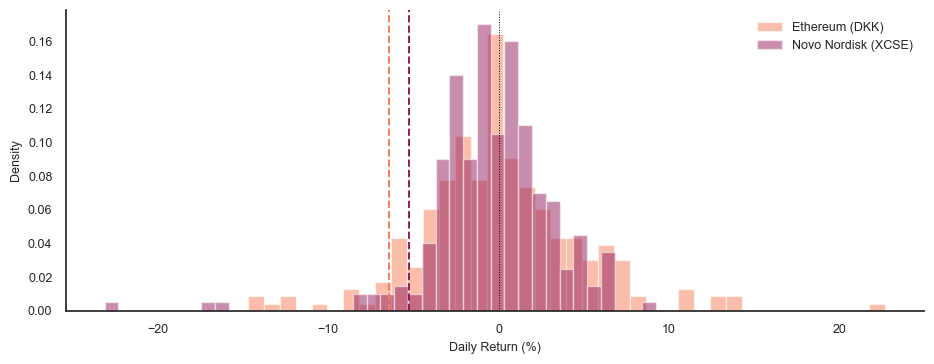

In [8]:
# Return distribution with 95% VaR threshold lines
set_clean_theme()
fig, ax = fig_ax(3.8)

for col, label in [('ret_eth', ASSET_LABELS['eth']), ('ret_novo', ASSET_LABELS['novo'])]:
    r = aligned_ts[col].dropna() * 100
    var_95 = np.percentile(r, 5)
    ax.hist(r, bins=40, alpha=0.50, color=ASSET_PALETTE[label], label=label, density=True)
    ax.axvline(var_95, color=ASSET_PALETTE[label], lw=1.4, ls='--')

ax.axvline(0, color='black', lw=0.7, ls=':')
ax.set_xlabel('Daily Return (%)', fontsize=9)
ax.set_ylabel('Density', fontsize=9)
ax.legend(fontsize=9, frameon=False)
clean_ax(ax)
fig.tight_layout()

print_figure('Daily return distribution with 95% VaR threshold (dashed lines): Ethereum vs Novo Nordisk')
plt.show()


### 1.4 Terminal RoI and DKK Value

We translate the terminal RoI into absolute DKK terms for a DKK 250,000 starting investment to make the result directly comparable with the assignment framing.


In [9]:
# Terminal RoI and DKK value for DKK 250,000 starting capital
terminal_roi_eth = aligned_ts['roi_eth'].iloc[-1]
terminal_roi_novo = aligned_ts['roi_novo'].iloc[-1]

terminal_val_eth = CAPITAL * (1 + terminal_roi_eth)
terminal_val_novo = CAPITAL * (1 + terminal_roi_novo)

terminal_df = pd.DataFrame({
    'Asset': [ASSET_LABELS['eth'], ASSET_LABELS['novo']],
    'Terminal RoI': [f'{terminal_roi_eth:.2%}', f'{terminal_roi_novo:.2%}'],
    'DKK Value (from 250,000)': [f'{terminal_val_eth:,.0f}', f'{terminal_val_novo:,.0f}'],
    'DKK Gain / Loss': [
        f'{terminal_val_eth - CAPITAL:+,.0f}',
        f'{terminal_val_novo - CAPITAL:+,.0f}',
    ],
}).set_index('Asset')

print_table('Terminal RoI and DKK outcome for DKK 250,000 invested at start of aligned sample')
display(terminal_df)


Table 3: Terminal RoI and DKK outcome for DKK 250,000 invested at start of aligned sample


,Terminal RoI,"DKK Value (from 250,000)",DKK Gain / Loss
Asset,,,
Ethereum (DKK),-20.27%,"199,330","-50,670"
Novo Nordisk (XCSE),-62.78%,"93,061","-156,939"


### 1.5 Asset Selection: Conclusion

Across all metrics computed on the aligned sample, Ethereum is the stronger single-asset choice for the observation period. Its Sharpe ratio is marginally positive, meaning it marginally compensated the investor for the volatility taken on, while Novo Nordisk's Sharpe ratio is deeply negative, reflecting a sustained price decline that was not offset by any return. The VaR and CVaR figures reveal an important nuance however: Ethereum's daily tail losses in DKK terms are larger in absolute magnitude due to its higher volatility, meaning an investor must be able to stomach larger single-day losses even if the cumulative outcome is better. The return distributions confirm that both assets exhibit fat tails and negative skew, so losses in bad periods are more severe than a normal distribution would suggest. The correlation between the two return series is low, which is an important input to Section 2: it means holding both assets simultaneously is not purely redundant and may reduce portfolio-level volatility relative to holding either asset alone. On the basis of RoI and risk-adjusted return over this specific window, the data favour Ethereum, but the VaR figures make clear this comes with material daily downside exposure.


---
# 2. Capital Allocation Strategy 

How should the DKK 250,000 be allocated? Should you adopt a pure 
strategy (100% allocation to one asset) or a hybrid strategy (e.g., X% in cryptocurrency and Y% in stock)?
What is the appropriate investment horizon (short-term vs. long-term; months vs. years)?

---

Next, we translate the asset level results into a portfolio decision. We examine whether a pure strategy, allocating 100% of the capital to either Ethereum or Novo Nordisk, is justified, or whether diversification benefits support a hybrid allocation across both assets. This section also addresses investment horizon by comparing outcomes over shorter horizons measured in months versus longer horizons measured in years, with attention to how volatility and drawdowns affect the practical feasibility of each strategy. 

## 2. Capital Allocation Strategy

Following the assignment brief, RoI remains the primary decision criterion, but I also use diversification logic from the course to check whether a hybrid portfolio improves the risk profile enough to justify giving up RoI. In line with Lecture 06, I compare portfolios using cumulative RoI, annualized volatility, Sharpe ratio, 95% VaR, and maximum drawdown. Because the two assets have low correlation, a mixed allocation can reduce risk even when one asset dominates on terminal RoI.

In [10]:
# Portfolio grid search from 0% to 100% ETH, rebalanced daily on aligned returns
portfolio_rows = []
weight_grid = np.round(np.linspace(0, 1, 21), 2)

for w_eth in weight_grid:
    w_novo = 1 - w_eth
    port_ret = w_eth * aligned_ts["ret_eth"].fillna(0) + w_novo * aligned_ts["ret_novo"].fillna(0)
    port_growth = (1 + port_ret).cumprod()
    port_roi = port_growth.iloc[-1] - 1
    ann_vol = port_ret.std() * np.sqrt(252)
    ann_ret = port_ret.mean() * 252
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    var_95 = -np.percentile(port_ret.dropna(), 5)
    drawdown = port_growth / port_growth.cummax() - 1
    max_drawdown = drawdown.min()

    portfolio_rows.append({
        "ETH Weight": w_eth,
        "NOVO Weight": w_novo,
        "Terminal RoI": port_roi,
        "Ann. Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Daily VaR 95%": var_95,
        "Max Drawdown": max_drawdown,
    })

portfolio_df = pd.DataFrame(portfolio_rows)

roi_best = portfolio_df.loc[portfolio_df["Terminal RoI"].idxmax()]
min_vol = portfolio_df.loc[portfolio_df["Ann. Volatility"].idxmin()]
best_var = portfolio_df.loc[portfolio_df["Daily VaR 95%"].idxmin()]

portfolio_display = portfolio_df.copy()
for col in ["ETH Weight", "NOVO Weight", "Terminal RoI", "Ann. Volatility", "Daily VaR 95%", "Max Drawdown"]:
    portfolio_display[col] = portfolio_display[col].map(lambda x: f"{x:.2%}")
portfolio_display["Sharpe Ratio"] = portfolio_df["Sharpe Ratio"].map(lambda x: f"{x:.3f}")

print_table("Portfolio grid: RoI and risk metrics across ETH/Novo allocations")
display(portfolio_display)

Table 4: Portfolio grid: RoI and risk metrics across ETH/Novo allocations


,ETH Weight,NOVO Weight,Terminal RoI,Ann. Volatility,Sharpe Ratio,Daily VaR 95%,Max Drawdown
0,0.00%,100.00%,-62.78%,56.35%,-1.483,5.23%,-62.78%
1,5.00%,95.00%,-60.57%,54.00%,-1.466,4.91%,-60.57%
2,10.00%,90.00%,-58.32%,51.93%,-1.439,4.45%,-58.32%
3,15.00%,85.00%,-56.03%,50.17%,-1.401,3.87%,-56.03%
4,20.00%,80.00%,-53.72%,48.77%,-1.351,3.52%,-53.72%
5,25.00%,75.00%,-51.39%,47.75%,-1.287,3.60%,-51.39%
6,30.00%,70.00%,-49.04%,47.14%,-1.210,3.66%,-49.04%
7,35.00%,65.00%,-46.70%,46.96%,-1.120,3.62%,-46.70%
8,40.00%,60.00%,-44.36%,47.20%,-1.021,3.80%,-45.91%
9,45.00%,55.00%,-42.03%,47.86%,-0.914,4.15%,-47.11%


Figure 2: Portfolio trade-off between terminal RoI and annualized volatility


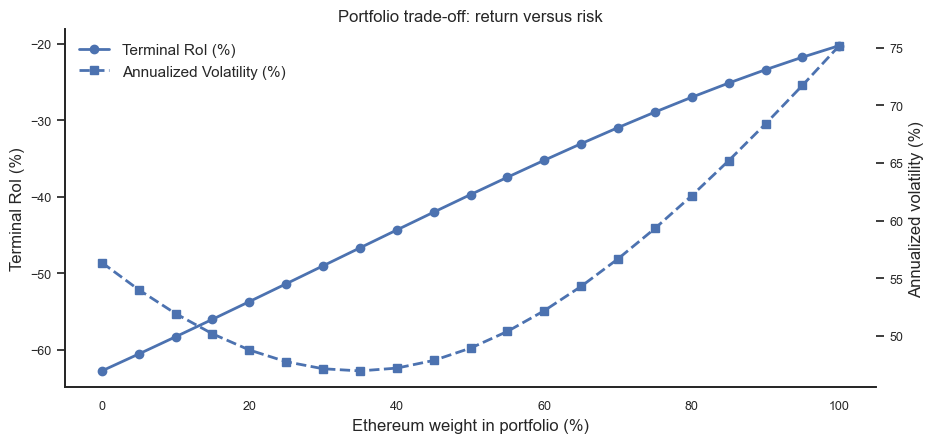

In [11]:
# Plot the RoI and volatility trade-off across portfolio weights
fig, ax1 = fig_ax(4.6)
ax2 = ax1.twinx()

ax1.plot(
    portfolio_df["ETH Weight"] * 100,
    portfolio_df["Terminal RoI"] * 100,
    marker="o",
    linewidth=2,
    label="Terminal RoI (%)"
)
ax2.plot(
    portfolio_df["ETH Weight"] * 100,
    portfolio_df["Ann. Volatility"] * 100,
    marker="s",
    linewidth=2,
    linestyle="--",
    label="Annualized Volatility (%)"
)

ax1.set_xlabel("Ethereum weight in portfolio (%)")
ax1.set_ylabel("Terminal RoI (%)")
ax2.set_ylabel("Annualized volatility (%)")
ax1.set_title("Portfolio trade-off: return versus risk")

clean_ax(ax1)
clean_ax(ax2)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, loc="best")

plt.tight_layout()
print_figure("Portfolio trade-off between terminal RoI and annualized volatility")
plt.show()

### 2.1 Investment Horizon

To address short term versus longer term holding periods, I compare rolling portfolio RoI over approximately 1 month (21 trading days), 3 months (63 trading days), and 6 months (126 trading days). This helps distinguish between allocations that are only acceptable over very short windows and allocations that become more robust when the investor can tolerate a longer holding period.

In [12]:
# Rolling horizon RoI for selected strategies
strategy_weights = {
    "Pure ETH (100/0)": 1.00,
    "Hybrid (80/20)": 0.80,
    "Hybrid (60/40)": 0.60,
    "Min-Vol (35/65)": float(min_vol["ETH Weight"]),
}

horizon_defs = {
    "1 Month": 21,
    "3 Months": 63,
    "6 Months": 126,
}

horizon_rows = []
for strategy, w_eth in strategy_weights.items():
    port_ret = w_eth * aligned_ts["ret_eth"].dropna() + (1 - w_eth) * aligned_ts["ret_novo"].dropna()

    for horizon_name, h in horizon_defs.items():
        rolling_roi = (1 + port_ret).rolling(h).apply(np.prod, raw=True) - 1
        rolling_roi = rolling_roi.dropna()

        horizon_rows.append({
            "Strategy": strategy,
            "Horizon": horizon_name,
            "Mean Rolling RoI": rolling_roi.mean(),
            "Median Rolling RoI": rolling_roi.median(),
            "Positive Window Share": (rolling_roi > 0).mean(),
            "Worst Window": rolling_roi.min(),
            "Best Window": rolling_roi.max(),
        })

horizon_df = pd.DataFrame(horizon_rows)
horizon_display = horizon_df.copy()

for col in ["Mean Rolling RoI", "Median Rolling RoI", "Positive Window Share", "Worst Window", "Best Window"]:
    horizon_display[col] = horizon_display[col].map(lambda x: f"{x:.2%}")

print_table("Rolling horizon RoI for pure and hybrid strategies")
display(horizon_display)

Table 5: Rolling horizon RoI for pure and hybrid strategies


,Strategy,Horizon,Mean Rolling RoI,Median Rolling RoI,Positive Window Share,Worst Window,Best Window
0,Pure ETH (100/0),1 Month,2.55%,-3.66%,42.73%,-43.04%,71.65%
1,Pure ETH (100/0),3 Months,18.36%,9.44%,56.76%,-50.39%,126.26%
2,Pure ETH (100/0),6 Months,38.15%,21.15%,73.77%,-61.78%,165.54%
3,Hybrid (80/20),1 Month,1.17%,-2.34%,47.14%,-38.99%,57.11%
4,Hybrid (80/20),3 Months,11.42%,6.66%,55.68%,-43.23%,94.87%
5,Hybrid (80/20),6 Months,24.03%,12.87%,72.13%,-55.77%,120.02%
6,Hybrid (60/40),1 Month,-0.17%,-0.84%,47.14%,-36.59%,43.25%
7,Hybrid (60/40),3 Months,5.05%,3.31%,54.05%,-35.63%,68.78%
8,Hybrid (60/40),6 Months,10.78%,2.97%,56.56%,-49.52%,79.35%
9,Min-Vol (35/65),1 Month,-1.81%,-2.31%,40.53%,-37.22%,31.03%


### 2.2 Capital Allocation: Conclusion

The portfolio grid gives a clear result. If the decision is made **strictly on ex post RoI**, the best allocation in this sample is a **pure Ethereum strategy (100% ETH, 0% Novo)**. This follows mechanically because both assets lost value over the aligned period, but Ethereum lost much less than Novo Nordisk. Any positive weight on Novo therefore drags terminal RoI down.

However, the risk results also show why a hybrid strategy can still be defensible. A mixed portfolio around **35% ETH and 65% Novo** minimizes annualized volatility, while a low ETH share around **20%** gives the lowest 95% daily VaR. In other words, diversification works in the textbook sense: low correlation reduces day to day portfolio risk. The trade-off is that this lower risk comes at the cost of materially weaker RoI.

For the DKK 250,000 allocation, my recommendation is therefore conditional on the investor objective:

1. **RoI maximizing investor:** allocate **DKK 250,000 to Ethereum**.
2. **Risk constrained investor who still wants crypto exposure:** use a **hybrid allocation, preferably around 80% ETH and 20% Novo**. This keeps most of the upside of the better asset while reducing volatility relative to pure ETH.
3. **Minimum volatility investor:** a **35% ETH and 65% Novo** mix is the defensive option, but it is unattractive if RoI is the primary metric.

The horizon analysis points toward a **medium to longer holding period rather than a very short one**. Over 1 month windows, outcomes are unstable for all strategies and especially for Ethereum. Over 3 month and 6 month windows, the ETH heavy portfolios show clearly better average RoI and a much larger share of positive windows than the more defensive allocations. Therefore, if one follows the data in this sample, the most reasonable implementation is **an ETH heavy allocation held for several months rather than traded over very short horizons**.

Overall, my answer to Q2 is: **choose a pure strategy if RoI is the main criterion, and choose a hybrid only if the investor has a binding risk constraint.**

---
# 3. Market Timing and Seasonality 

Are there identifiable seasonal patterns or cyclical trends in cryp-tocurrency and stock returns?
For example, are there specific months or periods that historically
yield higher average returns, suggesting a more favorable entry point?

---

Finally, we explore market timing and seasonality. Specifically, we test whether returns exhibit recurring monthly or cyclical patterns that could indicate more favorable entry periods, and we complement this with a regime based perspective that distinguishes between low volatility and high volatility phases. Where relevant, we additionally highlight extreme events and crash like periods to understand tail risk and its implications for allocation decisions.